In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/phone_usage_india.csv")

df.head()

,User ID,Age,Gender,Location,Phone Brand,OS,Screen Time (hrs/day),Data Usage (GB/month),Calls Duration (mins/day),Number of Apps Installed,Social Media Time (hrs/day),E-commerce Spend (INR/month),Streaming Time (hrs/day),Gaming Time (hrs/day),Monthly Recharge Cost (INR),Primary Use
0,U00001,53,Male,Mumbai,Vivo,Android,3.7,23.9,37.9,104,3.9,469,5.2,4.1,803,Education
1,U00002,60,Other,Delhi,Realme,iOS,9.2,28.1,13.7,169,2.8,4997,5.1,0.4,1526,Gaming
2,U00003,37,Female,Ahmedabad,Nokia,Android,4.5,12.3,66.8,96,3.0,2381,1.7,2.9,1619,Entertainment
3,U00004,32,Male,Pune,Samsung,Android,11.0,25.6,156.2,146,5.2,1185,3.2,0.3,1560,Entertainment
4,U00005,16,Male,Mumbai,Xiaomi,iOS,2.2,2.5,236.2,86,5.5,106,3.4,2.3,742,Social Media


In [ ]:
df.isnull().sum()

,0
User ID,0
Age,0
Gender,0
Location,0
Phone Brand,0
OS,0
Screen Time (hrs/day),0
Data Usage (GB/month),0
Calls Duration (mins/day),0
Number of Apps Installed,0


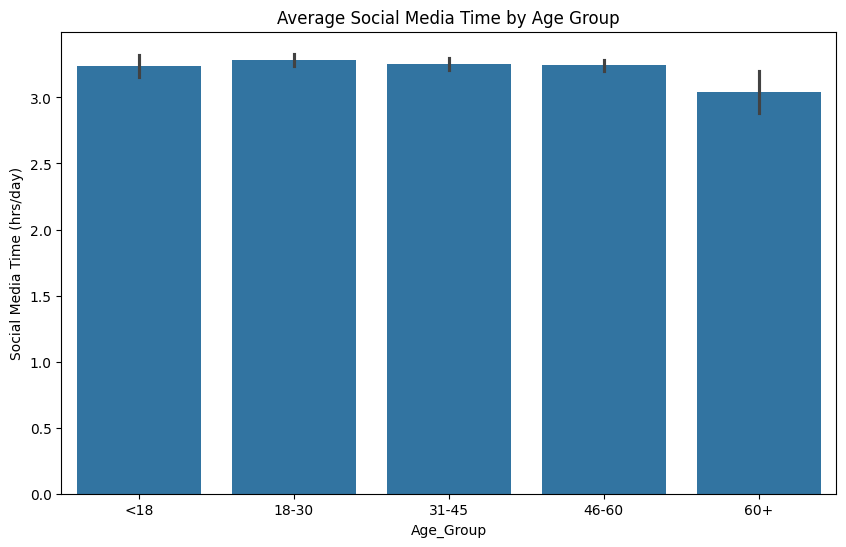

In [ ]:
import numpy as np

# Create age groups
bins = [0, 18, 30, 45, 60, np.inf]
labels = ['<18', '18-30', '31-45', '46-60', '60+']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Age_Group', y='Social Media Time (hrs/day)', data=df)

plt.title("Average Social Media Time by Age Group")
plt.show()

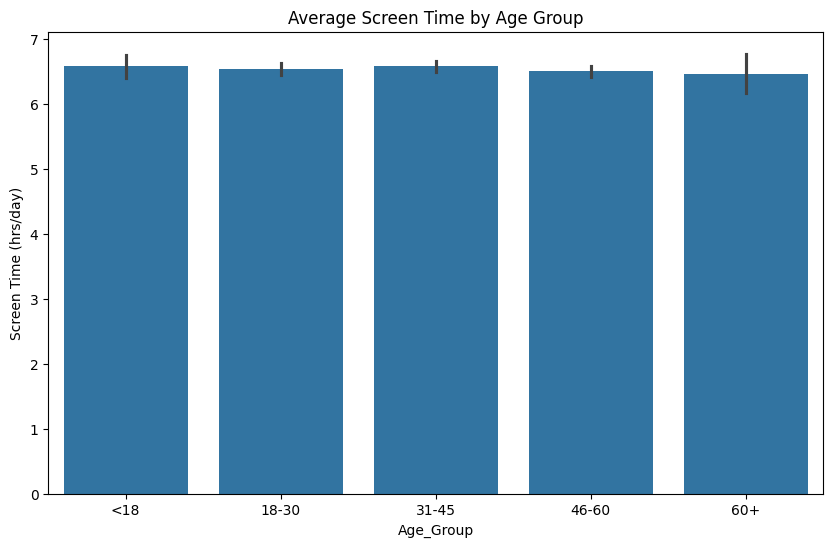

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x='Age_Group', y='Screen Time (hrs/day)', data=df)

plt.title("Average Screen Time by Age Group")
plt.show()

In [ ]:
# Create Addiction_Level based on Screen_Time and Social Media Usage
df['Addiction_Level'] = (
    (df['Screen Time (hrs/day)'] > 6).astype(int) +
    (df['Social Media Time (hrs/day)'] > 2).astype(int)
)

# Convert to binary: 1 = High Addiction, 0 = Low/Medium
df['Addiction_Level'] = df['Addiction_Level'].apply(lambda x: 1 if x > 1 else 0)

# Check result
df.head()

,User ID,Age,Gender,Location,Phone Brand,OS,Screen Time (hrs/day),Data Usage (GB/month),Calls Duration (mins/day),Number of Apps Installed,Social Media Time (hrs/day),E-commerce Spend (INR/month),Streaming Time (hrs/day),Gaming Time (hrs/day),Monthly Recharge Cost (INR),Primary Use,Age_Group,Addiction_Level
0,U00001,53,Male,Mumbai,Vivo,Android,3.7,23.9,37.9,104,3.9,469,5.2,4.1,803,Education,46-60,0
1,U00002,60,Other,Delhi,Realme,iOS,9.2,28.1,13.7,169,2.8,4997,5.1,0.4,1526,Gaming,60+,1
2,U00003,37,Female,Ahmedabad,Nokia,Android,4.5,12.3,66.8,96,3.0,2381,1.7,2.9,1619,Entertainment,31-45,0
3,U00004,32,Male,Pune,Samsung,Android,11.0,25.6,156.2,146,5.2,1185,3.2,0.3,1560,Entertainment,31-45,1
4,U00005,16,Male,Mumbai,Xiaomi,iOS,2.2,2.5,236.2,86,5.5,106,3.4,2.3,742,Social Media,<18,0


In [ ]:
# Create Eye/Ear Risk based on high Screen Time, Calling Time, and Gaming Time
df['Eye_Ear_Risk'] = (
    (df['Screen Time (hrs/day)'] > 6).astype(int) +    # High screen time
    (df['Calls Duration (mins/day)'] > 2).astype(int) +   # High calling time
    (df['Gaming Time (hrs/day)'] > 3).astype(int)      # High gaming time
)

# Convert to binary: 1 = High Risk, 0 = Low/Medium Risk
df['Eye_Ear_Risk'] = df['Eye_Ear_Risk'].apply(lambda x: 1 if x > 1 else 0)

# Check result
df[['Screen Time (hrs/day)', 'Calls Duration (mins/day)', 'Gaming Time (hrs/day)', 'Eye_Ear_Risk']].head()

,Screen Time (hrs/day),Calls Duration (mins/day),Gaming Time (hrs/day),Eye_Ear_Risk
0,3.7,37.9,4.1,1
1,9.2,13.7,0.4,1
2,4.5,66.8,2.9,0
3,11.0,156.2,0.3,1
4,2.2,236.2,2.3,0


In [ ]:
# Count of High vs Low/Medium Addiction
df['Addiction_Level'].value_counts()

# Percentage
df['Addiction_Level'].value_counts(normalize=True) * 100

,proportion
Addiction_Level,
0,60.754269
1,39.245731


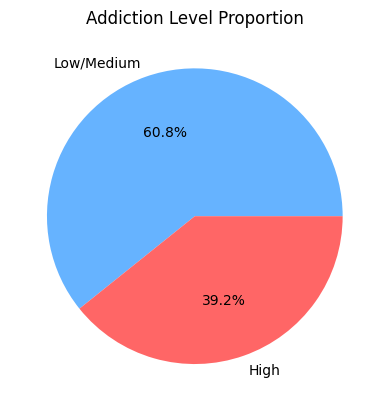

In [ ]:
import matplotlib.pyplot as plt

df['Addiction_Level'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['Low/Medium','High'], colors=['#66b3ff','#ff6666']
)
plt.title("Addiction Level Proportion")
plt.ylabel('')
plt.show()

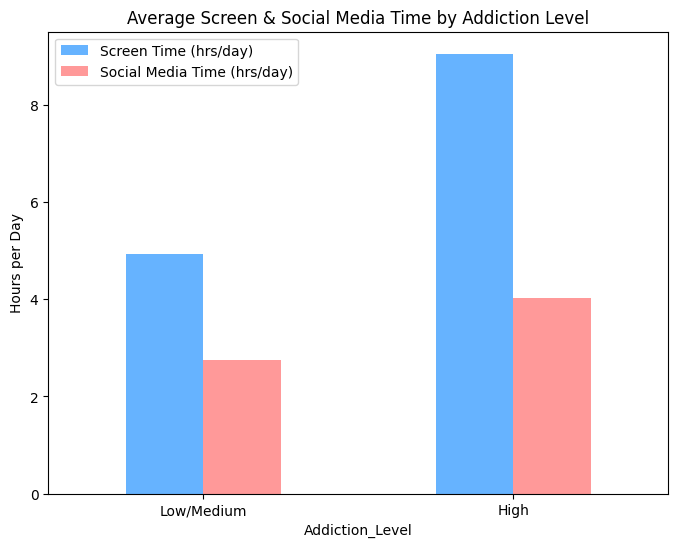

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute mean values
mean_values = df.groupby('Addiction_Level')[['Screen Time (hrs/day)', 'Social Media Time (hrs/day)']].mean()

# Plot
mean_values.plot(kind='bar', figsize=(8,6), color=['#66b3ff','#ff9999'])
plt.xticks([0,1], ['Low/Medium', 'High'], rotation=0)
plt.title("Average Screen & Social Media Time by Addiction Level")
plt.ylabel("Hours per Day")
plt.show()

In [ ]:
# Create Eye/Ear Risk based on high Screen Time, Calling Time, and Gaming Time
df['Eye_Ear_Risk'] = (
    (df['Screen Time (hrs/day)'] > 6).astype(int) +    # High screen time
    (df['Calls Duration (mins/day)'] > 120).astype(int) +   # High calling time (2 hours = 120 minutes)
    (df['Gaming Time (hrs/day)'] > 3).astype(int)      # High gaming time
)

# Convert to binary: 1 = High Risk, 0 = Low/Medium Risk
df['Eye_Ear_Risk'] = df['Eye_Ear_Risk'].apply(lambda x: 1 if x > 1 else 0)

# Check result
df[['Screen Time (hrs/day)', 'Calls Duration (mins/day)', 'Gaming Time (hrs/day)', 'Eye_Ear_Risk']].head()

,Screen Time (hrs/day),Calls Duration (mins/day),Gaming Time (hrs/day),Eye_Ear_Risk
0,3.7,37.9,4.1,0
1,9.2,13.7,0.4,0
2,4.5,66.8,2.9,0
3,11.0,156.2,0.3,1
4,2.2,236.2,2.3,0


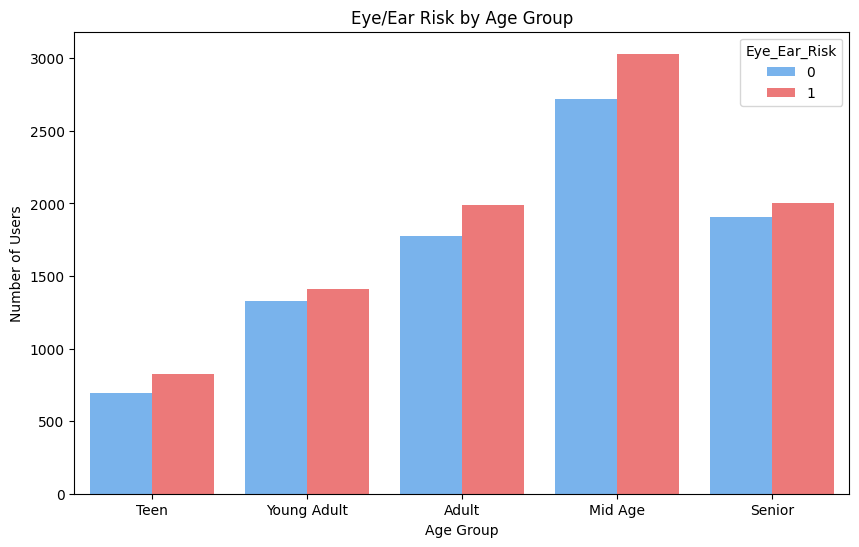

In [ ]:
# Ensure Age_Group column exists
df['Age_Group'] = pd.cut(df['Age'], bins=[10,18,25,35,50,70],
                         labels=['Teen','Young Adult','Adult','Mid Age','Senior'])

plt.figure(figsize=(10,6))
sns.countplot(x='Age_Group', hue='Eye_Ear_Risk', data=df, palette=['#66b3ff','#ff6666'])
plt.title("Eye/Ear Risk by Age Group")
plt.ylabel("Number of Users")
plt.xlabel("Age Group")
plt.show()

In [ ]:
df.groupby('Addiction_Level')[['Screen Time (hrs/day)','Social Media Time (hrs/day)','Gaming Time (hrs/day)']].mean()

,Screen Time (hrs/day),Social Media Time (hrs/day),Gaming Time (hrs/day)
Addiction_Level,,,
0,4.928646,2.756854,2.504458
1,9.050699,4.019450,2.469846


In [ ]:
df.groupby('Eye_Ear_Risk')[['Screen Time (hrs/day)','Calls Duration (mins/day)','Gaming Time (hrs/day)']].mean()

,Screen Time (hrs/day),Calls Duration (mins/day),Gaming Time (hrs/day)
Eye_Ear_Risk,,,
0,5.084805,113.650214,1.866607
1,7.875707,185.745455,3.058659


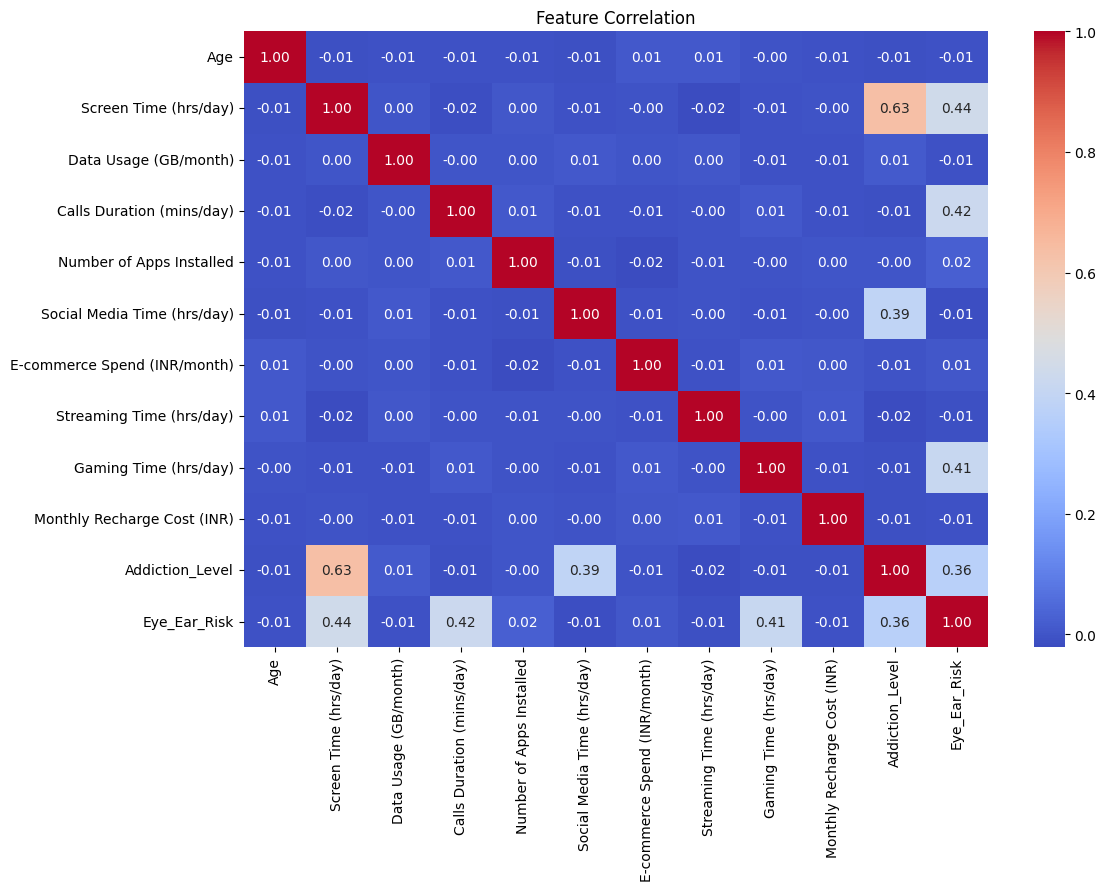

In [ ]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation")
plt.show()